# Repeated games: an Axelrod-style tournament

This worked experiment asks three questions: which strategies score well against this field, does winning individual matches predict tournament success, and how robust are the results to the simulation conditions?

This is a small teaching tournament, not a reproduction of Axelrod’s historical entrants or rankings. It includes later strategies as well as familiar early ones. We implement the rules directly so that every decision can be inspected. NumPy and Matplotlib are the only dependencies; run the notebook from top to bottom.

The sequence is one match → repeated round-robin tournaments → opponent-level explanation → controlled sensitivity tests. There is no reproduction, selection or mutation of strategies here. Those belong to the subsequent evolutionary model.

## Specify the experiment before running it

| Choice | Baseline |
|---|---|
| Payoffs | temptation 5, mutual-cooperation reward 3, mutual-defection punishment 1, sucker’s payoff 0; higher is better |
| Match | 200 simultaneous rounds, all rounds weighted equally; strategies do not receive the stopping round |
| Opponents | seven named strategies, equally weighted |
| Self-play | included, using two separate copies; their scores are averaged into one opponent contribution |
| Repetitions | 30 complete tournaments, with independently seeded matches |
| Noise | zero in the baseline; extensions independently flip each intended action with a stated probability |
| Memory | realised actions from the current match only; reset between matches |
| Ranking | median across repetitions of each strategy’s mean payoff per round across opponents |
| Wins | fraction of non-self matches in which the focal player strictly outscores its opponent; draws are not wins |

These positive payoffs are the conventional tournament example, not a change of sign in the reader’s prison sentences. Both matrices satisfy the prisoner’s-dilemma ordering, but their numerical incentives differ. The fixed horizon is a simulation budget, not a claim that these rules are equilibrium strategies for a known finite-horizon game.

A tournament repetition is one independent realisation of all matches. The middle-50% intervals below describe variation between repetitions, not confidence intervals for a mean and not variation between agents within one match.

### Strategies

| Strategy | Rule |
|---|---|
| Always Cooperate | always C |
| Always Defect | always D |
| Tit for Tat | start C, then copy the opponent’s previous realised action |
| Grudger | start C; after any opponent defection, defect for the rest of this match |
| Tit for Two Tats | defect only after two consecutive opponent defections; otherwise C |
| Random | independently choose C or D with equal probability each round |
| Win-Stay Lose-Shift | start C; keep the previous action after reward 3 or temptation 5, otherwise switch |

Both choices use the same completed history. Only after both choices are made do we apply action errors, assign payoffs and append the realised actions. This prevents the player processed second from seeing the opponent’s current choice. Action errors are not observation errors: both players see what actually happened.

In [1]:
"""Small, inspectable Axelrod-style tournament; not the historical entry list.

C=0, D=1. Strategies see completed, realised actions only. Payoffs are
(T,R,P,S)=(5,3,1,0); no discounting, horizon information or inter-match memory.
Only NumPy is required. The companion notebook embeds this source verbatim.
"""
import numpy as np

STRATEGIES = (
    'Always Cooperate', 'Always Defect', 'Tit for Tat', 'Grudger',
    'Tit for Two Tats', 'Random', 'Win-Stay Lose-Shift',
)


def choose_action(name, own, other, rng):
    """Return an intended action from immutable completed histories."""
    if name == 'Always Cooperate':
        return 0
    if name == 'Always Defect':
        return 1
    if name == 'Random':
        return int(rng.integers(2))
    if name == 'Tit for Tat':
        return other[-1] if other else 0
    if name == 'Grudger':
        return int(1 in other)
    if name == 'Tit for Two Tats':
        return int(len(other) >= 2 and other[-2:] == (1, 1))
    if name == 'Win-Stay Lose-Shift':
        # With these PD payoffs, R and T are satisfactory; P and S are not.
        # Start C, then C after CC or DD, D after CD or DC.
        return int(own[-1] != other[-1]) if own else 0
    raise ValueError(f'Unknown strategy: {name}')


def _positive_integer(value, name):
    if isinstance(value, (bool, np.bool_)) or not isinstance(value, (int, np.integer)) or value < 1:
        raise ValueError(f'{name} must be a positive integer')


def play_match(left, right, rounds=200, noise=0.0, seed=0,
               payoffs=(5, 3, 1, 0), forced_flips=()):
    """One simultaneous match; noise independently flips each intended action.

    forced_flips is for controlled demonstrations: (zero-based round, seat).
    A forced flip applies after random noise. Histories reset on every call.
    """
    _positive_integer(rounds, 'rounds')
    if left not in STRATEGIES or right not in STRATEGIES:
        raise ValueError('Unknown strategy')
    if not np.isfinite(noise) or not 0 <= noise <= 1:
        raise ValueError('noise must be between 0 and 1')
    T, R, P, S = payoffs
    if not np.all(np.isfinite(payoffs)) or not T > R > P > S:
        raise ValueError('Payoffs must be finite and satisfy T > R > P > S')
    flips = set(forced_flips)
    if any(not (isinstance(t, int) and 0 <= t < rounds and seat in (0, 1)) for t, seat in flips):
        raise ValueError('Invalid forced flip')
    streams = [np.random.default_rng(s) for s in np.random.SeedSequence(seed).spawn(3)]
    reward = np.array([[[R, R], [S, T]], [[T, S], [P, P]]], dtype=float)
    actions = np.empty((rounds, 2), dtype=np.int8)
    intended = np.empty_like(actions)
    scores = np.empty((rounds, 2))
    histories = [(), ()]
    for t in range(rounds):
        a = choose_action(left, histories[0], histories[1], streams[0])
        b = choose_action(right, histories[1], histories[0], streams[1])
        intended[t] = (a, b)
        actual = intended[t] ^ (streams[2].random(2) < noise).astype(np.int8)
        for seat in (0, 1):
            actual[seat] ^= int((t, seat) in flips)
        actions[t] = actual
        scores[t] = reward[actual[0], actual[1]]
        # Update both histories only after both choices have been made.
        histories = [histories[i] + (int(actual[i]),) for i in (0, 1)]
    return {'actions': actions, 'intended': intended, 'scores': scores,
            'cumulative_scores': scores.cumsum(axis=0),
            'mean_scores': scores.mean(axis=0),
            'cooperation': (actions == 0).mean(axis=0)}


def run_tournament(players=STRATEGIES, rounds=200, repetitions=30,
                   noise=0.0, seed=3024, self_play=True, payoffs=(5, 3, 1, 0)):
    """Round robin; equal opponent weights; one independent match per pair.

    Arrays use [repetition, focal strategy, opponent]. Self-play represents
    two separate copies, averaged into one opponent contribution. Missing
    diagonal entries are NaN when self-play is excluded. Stable pair seeds
    make results invariant to the order of the entrants.
    """
    players = tuple(players)
    _positive_integer(rounds, 'rounds')
    _positive_integer(repetitions, 'repetitions')
    if len(players) < 2 or len(set(players)) != len(players) or any(p not in STRATEGIES for p in players):
        raise ValueError('Use at least two distinct known strategies')
    shape = (repetitions, len(players), len(players))
    payoff = np.full(shape, np.nan)
    cooperation = np.full(shape, np.nan)
    wins = np.full(shape, np.nan)
    for r in range(repetitions):
        for i in range(len(players)):
            for j in range(i if self_play else i + 1, len(players)):
                ids = [STRATEGIES.index(players[i]), STRATEGIES.index(players[j])]
                a, b = sorted(ids)
                pair_seed = [int(seed), r, a, b]
                match = play_match(STRATEGIES[a], STRATEGIES[b], rounds, noise, pair_seed, payoffs)
                means, cs = match['mean_scores'], match['cooperation']
                if i == j:
                    payoff[r, i, i] = means.mean()
                    cooperation[r, i, i] = cs.mean()
                else:
                    order = [0, 1] if ids == [a, b] else [1, 0]
                    x, y = means[order]
                    cx, cy = cs[order]
                    payoff[r, i, j], payoff[r, j, i] = x, y
                    cooperation[r, i, j], cooperation[r, j, i] = cx, cy
                    wins[r, i, j], wins[r, j, i] = float(x > y + 1e-12), float(y > x + 1e-12)
    return {'players': players, 'rounds': rounds, 'repetitions': repetitions,
            'noise': noise, 'seed': seed, 'self_play': self_play, 'payoffs': tuple(payoffs),
            'pair_payoff': payoff, 'pair_cooperation': cooperation,
            'scores': np.nanmean(payoff, axis=2),
            'cooperation': np.nanmean(cooperation, axis=2),
            # Self-play is never a head-to-head win. Draws count as zero wins.
            'win_fraction': np.nanmean(wins, axis=2)}


def summarise(result):
    """Rank by median score across repetitions; tied medians share a rank."""
    median = np.median(result['scores'], axis=0)
    q1, q3 = np.quantile(result['scores'], [.25, .75], axis=0)
    records = []
    for i in np.argsort(-median, kind='stable'):
        records.append({'strategy': result['players'][i],
                        'rank': 1 + int(np.sum(median > median[i] + 1e-12)),
                        'median_score': float(median[i]), 'q25': float(q1[i]), 'q75': float(q3[i]),
                        'cooperation': float(result['cooperation'][:, i].mean()),
                        'win_fraction': float(result['win_fraction'][:, i].mean())})
    return records

## Check familiar encounters first

Tit for Tat against Always Defect is exploited once, then both defect. Over 200 rounds their total scores should be 199 and 204. A single forced error in Tit for Tat self-play should be followed by alternating retaliation; this is a check of timing, not tournament evidence.

In [2]:
assert np.allclose(play_match('Always Cooperate', 'Always Cooperate')['mean_scores'], (3,3))
assert np.allclose(play_match('Always Defect', 'Always Cooperate')['mean_scores'], (5,0))
assert np.allclose(play_match('Tit for Tat', 'Always Defect')['mean_scores'] * 200, (199,204))
check = play_match('Tit for Tat', 'Tit for Tat', rounds=5, forced_flips=((1,0),))
assert np.array_equal(check['actions'], [[0,0],[1,0],[0,1],[1,0],[0,1]])
print('Known-answer and simultaneous-update checks passed.')

Known-answer and simultaneous-update checks passed.


In [3]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
plt.rcParams.update({'font.size': 11, 'axes.spines.top': False, 'axes.spines.right': False,
                     'figure.dpi': 110, 'savefig.bbox': 'tight'})
colours = ['#347eaf', '#dc603d', '#17294f', '#239a83', '#8650af', '#b68b22', '#667585']
short = ['Always C', 'Always D', 'Tit for Tat', 'Grudger', 'Two Tats', 'Random', 'Win-Stay Lose-Shift']

## Inspect one match

The top panels show realised actions, one row per player. The lower panels show accumulated payoff. The second match has exactly one imposed error in round 5 (player 1), not continuing random noise. Read the action histories to explain the score curves before interpreting a tournament average.

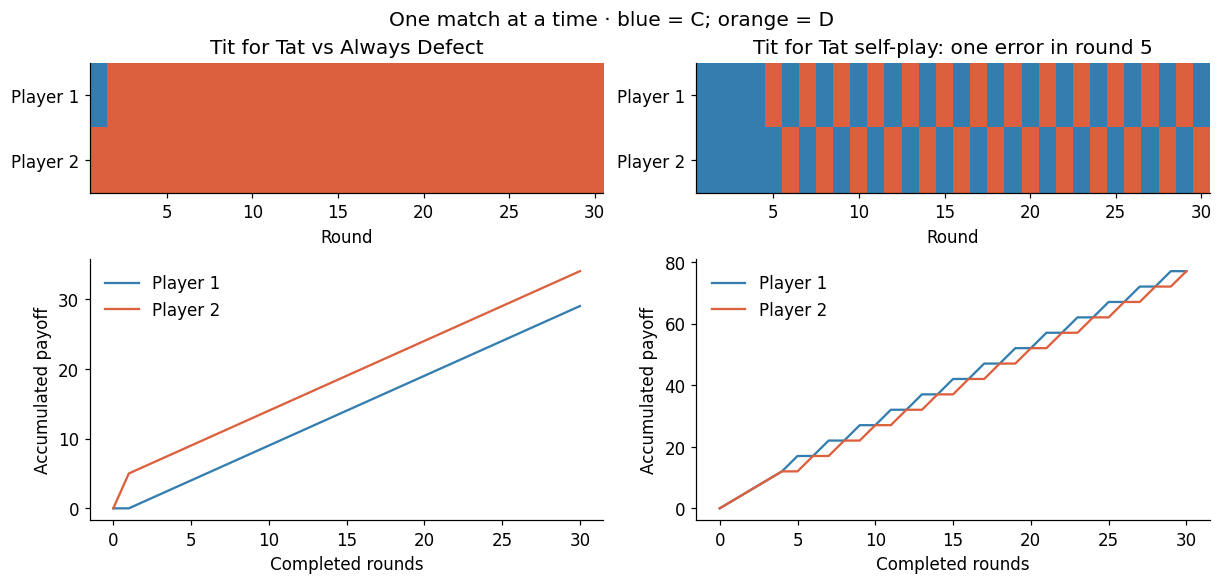

In [4]:
examples = [
    ('Tit for Tat vs Always Defect', play_match('Tit for Tat','Always Defect',rounds=30)),
    ('Tit for Tat self-play: one error in round 5',
     play_match('Tit for Tat','Tit for Tat',rounds=30,forced_flips=((4,0),))),
]
fig, axes = plt.subplots(2,2,figsize=(11,5.2),layout='constrained',gridspec_kw={'height_ratios':[1,2]})
for col, (title, match) in enumerate(examples):
    axes[0,col].imshow(match['actions'].T, cmap=ListedColormap(colours[:2]),
                       vmin=0,vmax=1,aspect='auto',extent=(.5,30.5,2.5,.5))
    axes[0,col].set(title=title,yticks=[1,2],yticklabels=['Player 1','Player 2'],xlabel='Round')
    for seat in (0,1):
        axes[1,col].plot(np.arange(31),np.r_[0,match['cumulative_scores'][:,seat]],
                         color=colours[seat],label=f'Player {seat+1}')
    axes[1,col].set(xlabel='Completed rounds',ylabel='Accumulated payoff')
    axes[1,col].legend(frameon=False)
fig.suptitle('One match at a time · blue = C; orange = D')
plt.show()

## Repeat the round robin

Each pair meets once per repetition. Seven entrants with self-play give 28 matches per repetition, or 840 matches in the baseline. Each match evaluates both players for the same number of rounds. All observations are stored in the arrays returned by `run_tournament`.

Rank by payoff, not by the number of opponents beaten. When comparing repetitions, keep the field and opponent weights fixed.

In [5]:
baseline = run_tournament(rounds=200,repetitions=30,noise=0,seed=3024)
rows = summarise(baseline)
print(f"{'Rank':<5} {'Strategy':<23} {'Median':>7} {'Middle 50%':>17} {'Coop.':>7} {'Wins':>7}")
for row in rows:
    print(f"{row['rank']:<5} {row['strategy']:<23} {row['median_score']:7.3f} "
          f"[{row['q25']:.3f}, {row['q75']:.3f}] {row['cooperation']:10.3f} {row['win_fraction']:7.3f}")

Rank  Strategy                 Median        Middle 50%   Coop.    Wins
1     Grudger                   2.716 [2.706, 2.726]      0.717   0.167
2     Tit for Tat               2.610 [2.605, 2.616]      0.789   0.000
3     Tit for Two Tats          2.552 [2.542, 2.558]      0.823   0.000
4     Win-Stay Lose-Shift       2.537 [2.521, 2.548]      0.858   0.083
5     Always Cooperate          2.358 [2.349, 2.367]      1.000   0.000
6     Always Defect             2.156 [2.141, 2.174]      0.000   1.000
7     Random                    2.135 [2.119, 2.150]      0.505   0.483


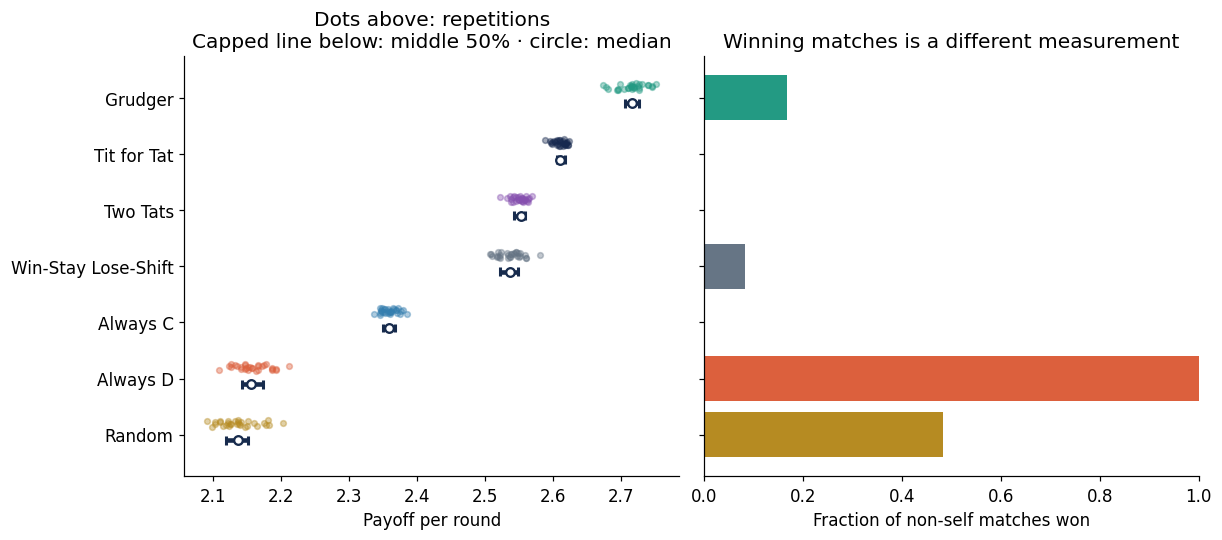

In [6]:
order = [baseline['players'].index(row['strategy']) for row in rows]
fig, axes = plt.subplots(1,2,figsize=(11,4.8),layout='constrained',sharey=True)
for y,i in enumerate(order):
    q1,med,q3 = np.quantile(baseline['scores'][:,i],[.25,.5,.75])
    axes[0].scatter(baseline['scores'][:,i],y-.20+np.linspace(-.06,.06,30),s=14,alpha=.4,color=colours[i])
    axes[0].plot([q1,q3],[y+.10,y+.10],lw=3,color='#172b4d',solid_capstyle='butt',zorder=3)
    axes[0].vlines([q1,q3],y+.02,y+.18,color='#172b4d',lw=2,zorder=3)
    axes[0].scatter(med,y+.10,facecolor='white',edgecolor='#172b4d',linewidth=1.5,s=32,zorder=4)
    axes[1].barh(y,baseline['win_fraction'][:,i].mean(),color=colours[i])
axes[0].set(yticks=range(7),yticklabels=[short[i] for i in order],xlabel='Payoff per round',
            title='Dots above: repetitions\nCapped line below: middle 50% · circle: median')
axes[0].invert_yaxis()
axes[1].set(xlabel='Fraction of non-self matches won',xlim=(0,1),title='Winning matches is a different measurement')
plt.show()

## Explain the ranking opponent by opponent

Rows are focal strategies; columns are opponents. The left matrix is the mean payoff per round across repetitions. The right matrix is the fraction of the focal player’s realised actions that were cooperative, averaged over repetitions. It is not the fraction of rounds in which both players cooperated. The diagonal averages the two copies in self-play.

Use these matrices to find out who supplies each strategy’s high scores and who exploits it. An overall ranking hides this structure.

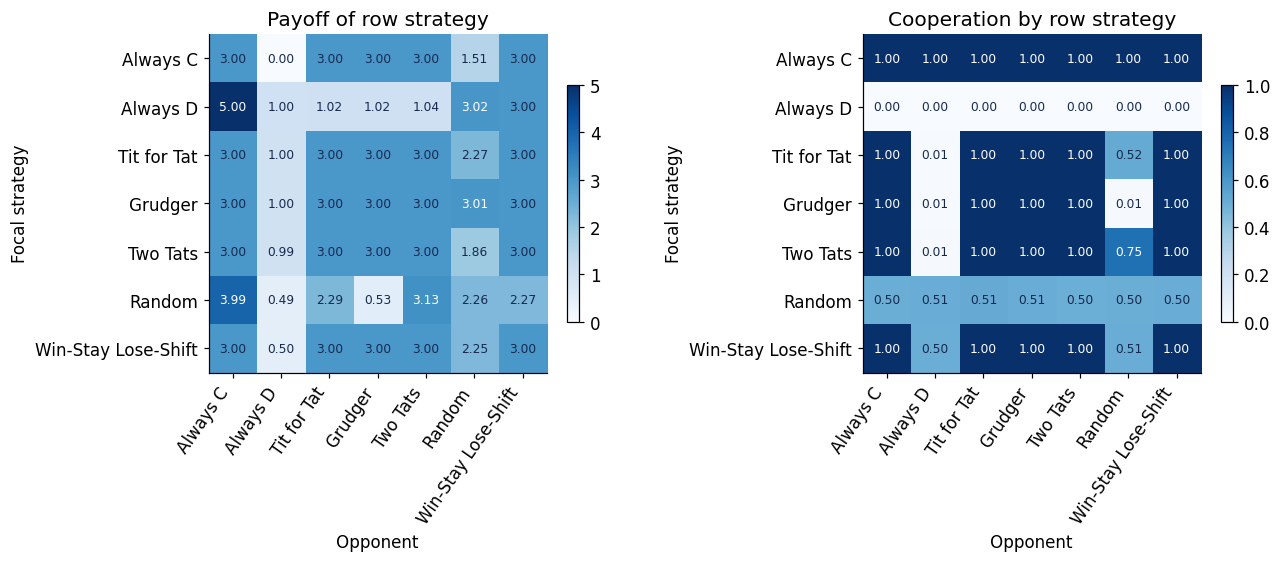

In [7]:
fig, axes = plt.subplots(1,2,figsize=(12,5),layout='constrained')
for ax, data, title, upper in zip(axes,
    [baseline['pair_payoff'].mean(axis=0), baseline['pair_cooperation'].mean(axis=0)],
    ['Payoff of row strategy', 'Cooperation by row strategy'], [5,1]):
    im=ax.imshow(data,cmap='Blues',vmin=0,vmax=upper)
    ax.set(xticks=range(7),yticks=range(7),xticklabels=short,yticklabels=short,
           xlabel='Opponent',ylabel='Focal strategy',title=title)
    plt.setp(ax.get_xticklabels(),rotation=55,ha='right')
    for i in range(7):
        for j in range(7):ax.text(j,i,f'{data[i,j]:.2f}',ha='center',va='center',fontsize=8,
                                  color='white' if data[i,j]>.6*upper else '#17294f')
    fig.colorbar(im,ax=ax,shrink=.7)
plt.show()

## Test sensitivity, one choice at a time

Before running these comparisons, predict which strategies will be damaged by a mistaken defection and which can recover. Keep the entrant field, payoff matrix and scoring convention fixed. First vary match length without noise; then vary action-error probability at 200 rounds. The curves show four contrasting strategies for readability; all seven remain in every tournament and in the saved arrays.

Each point summarises 30 complete repetitions. Shading is the middle 50% of tournament scores, not uncertainty in a mean. Pair seeds are matched between conditions, so a paired difference—not an independent-samples calculation—is appropriate if quantifying the change.

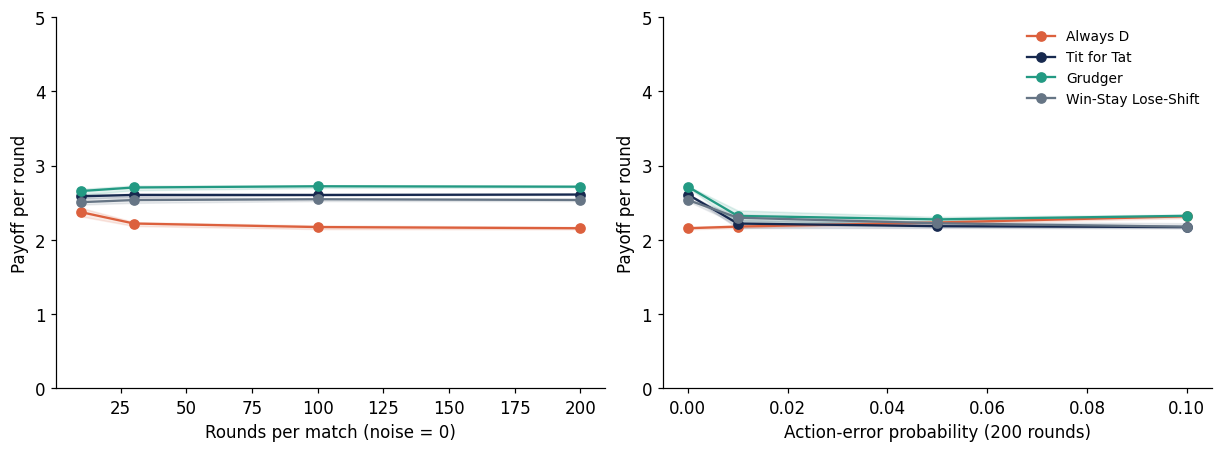

In [8]:
lengths = [10,30,100,200]
noises = [0,.01,.05,.10]
length_results = [run_tournament(rounds=n,repetitions=30,seed=3024) for n in lengths]
noise_results = [run_tournament(rounds=200,repetitions=30,noise=e,seed=3024) for e in noises]
fig, axes=plt.subplots(1,2,figsize=(11,4),layout='constrained')
for ax,x,results,label in zip(axes,[lengths,noises],[length_results,noise_results],
                             ['Rounds per match (noise = 0)','Action-error probability (200 rounds)']):
    for i in [1,2,3,6]:
        q=np.array([np.quantile(r['scores'][:,i],[.25,.5,.75]) for r in results])
        ax.plot(x,q[:,1],'o-',color=colours[i],label=short[i])
        ax.fill_between(x,q[:,0],q[:,2],color=colours[i],alpha=.13)
    ax.set(xlabel=label,ylabel='Payoff per round',ylim=(0,5))
axes[1].legend(frameon=False,fontsize=9)
plt.show()

### Change the opponent field

Remove Always Cooperate and rerun the tournament. This changes the opponents, not the rules of the remaining strategies. With equal weights the remaining opponents also receive greater weight. Excluding self-play is a separate comparison.

The seed scheme preserves each surviving pair’s match history. This isolates the field/scoring change rather than introducing a new random sample of those encounters. Report the field whenever reporting a winner.

In [9]:
without_cooperator = run_tournament(players=STRATEGIES[1:],seed=3024)
without_self = run_tournament(self_play=False,seed=3024)
for label,result in [('Baseline',baseline),('No Always Cooperate',without_cooperator),('No self-play',without_self)]:
    print(label)
    print(', '.join(f"{r['rank']}: {r['strategy']} ({r['median_score']:.3f})" for r in summarise(result)))
for epsilon,result in zip(noises,noise_results):
    i=result['players'].index('Tit for Tat')
    differences=result['scores'][:,i]-baseline['scores'][:,i]
    print(f'Noise {epsilon:.2f}: median paired change for Tit for Tat = {np.median(differences):+.3f}')

Baseline
1: Grudger (2.716), 2: Tit for Tat (2.610), 3: Tit for Two Tats (2.552), 4: Win-Stay Lose-Shift (2.537), 5: Always Cooperate (2.358), 6: Always Defect (2.156), 7: Random (2.135)
No Always Cooperate
1: Grudger (2.668), 2: Tit for Tat (2.545), 3: Tit for Two Tats (2.478), 4: Win-Stay Lose-Shift (2.460), 5: Random (1.820), 6: Always Defect (1.682)
No self-play
1: Grudger (2.668), 2: Tit for Tat (2.545), 3: Tit for Two Tats (2.478), 4: Win-Stay Lose-Shift (2.460), 5: Always Defect (2.348), 6: Always Cooperate (2.251), 7: Random (2.115)
Noise 0.00: median paired change for Tit for Tat = +0.000
Noise 0.01: median paired change for Tit for Tat = -0.398
Noise 0.05: median paired change for Tit for Tat = -0.430
Noise 0.10: median paired change for Tit for Tat = -0.437


## What does the experiment support?

- Explain a high or low tournament score using the pairwise matrices and a specific match history.
- Distinguish a median-score ranking from head-to-head wins. Preserve ties; small observed differences do not establish a robust ordering.
- State whether changing match length, noise or the entrant field changes your conclusion. More repetitions address simulation variability; they do not fix an unrepresentative opponent field.
- A tournament keeps the strategy field fixed. It does not show invasion, evolutionary stability or which strategy becomes common.

The baseline includes deterministic and stochastic encounters. Repeating an entirely deterministic, noise-free field produces identical results; more identical repetitions would add no evidence about robustness.

<div class="discussion-marker"><img src="images/discussion_marker.svg" alt="Discussion prompt"><span>Can a strategy score well without beating its opponents? Which opponent-level results explain your answer, and would the conclusion survive a different field?</span></div>

## Record the evidence

The following cell saves the complete per-repetition payoff and cooperation matrices, strategy scores, sensitivity arrays, settings and ranking tables in a local `tournament_results` folder. No data are sent elsewhere. The match seed is determined by the master seed, repetition and stable pair identifiers; record the NumPy version as well as the seed.

In [10]:
import csv, json
from pathlib import Path
out=Path('tournament_results')
out.mkdir(exist_ok=True)
settings={k:baseline[k] for k in ['players','rounds','repetitions','noise','seed','self_play','payoffs']}
settings.update(numpy_version=np.__version__,lengths=lengths,noises=noises,
                ranking='median across repetitions of mean payoff per round; equal opponent weights',
                self_play_weight='one opponent contribution, average of both seats',
                wins='non-self strict wins; draws count as zero',
                historical_reproduction=False)
(out/'settings.json').write_text(json.dumps(settings,indent=2))
np.savez_compressed(out/'results.npz',**{k:baseline[k] for k in
    ['pair_payoff','pair_cooperation','scores','cooperation','win_fraction']},
    length_scores=np.stack([r['scores'] for r in length_results]),
    noise_scores=np.stack([r['scores'] for r in noise_results]),
    no_cooperator_scores=without_cooperator['scores'],no_self_scores=without_self['scores'])
with (out/'ranking.csv').open('w',newline='') as f:
    writer=csv.DictWriter(f,fieldnames=rows[0].keys()); writer.writeheader(); writer.writerows(rows)
print(out.resolve())

/Users/sam/Desktop/TEACHING/MATH3024/JL_Reader/my-complex-systems-book/notebooks/week10/tournament_results


## Sources and relation to standard practice

The [Axelrod-Python tournament summaries](https://axelrod.readthedocs.io/en/stable/tutorials/new_to_game_theory_and_or_python/summarising_tournaments.html) report median scores, cooperation and wins. Its [noise example](https://axelrod.readthedocs.io/en/dev/how-to/include_noise.html) defines noise as independent action flips. We use these measurements, state the weighting and self-play conventions explicitly, and add controlled match-length and opponent-field checks.

The library’s [first-tournament reconstruction](https://axelrod.readthedocs.io/en/stable/tutorials/running_axelrods_first_tournament/) uses 200 turns and five repetitions with the historical strategy descriptions. It cautions that some original descriptions are ambiguous and reconstructed rankings can differ. Our seven-entry example is deliberately not that reconstruction; it uses 30 repetitions for its stochastic comparisons. Win-Stay Lose-Shift and Tit for Two Tats are included for comparison, not presented as original first-tournament entrants.

For the historical result, see Axelrod and Hamilton, [*The evolution of cooperation*](https://doi.org/10.1126/science.7466396).